In [4]:
import random
import pandas as pd
import numpy as np
import pwlf

RANDOM_STATE = 123
random.seed(RANDOM_STATE)

N = 20
df_name = "AAPL_1min"

df = pd.read_csv(f'../datasets/{df_name}_marked.csv')

TRAIN_SIZE = int(0.9 * df.shape[0])
df_train, df_test = df[:TRAIN_SIZE], df[TRAIN_SIZE:]

In [5]:
def build_min_vectors_by_slopes(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_min'] or take_all:
            x = np.arange(N + 1)
            y = df.iloc[i-N:i + 1]['open'].values
            model = pwlf.PiecewiseLinFit(x, y)
            _ = model.fit(4)
            vectors.append(model.slopes)
    return np.array(vectors)

def build_max_vectors_by_slopes(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_max'] or take_all:
            x = np.arange(N + 1)
            y = df.iloc[i-N:i + 1]['open'].values
            model = pwlf.PiecewiseLinFit(x, y)
            _ = model.fit(4)
            vectors.append(model.slopes)
    return np.array(vectors)

X_train_min = build_min_vectors_by_slopes(df_train, N)
X_train_max = build_max_vectors_by_slopes(df_train, N)
print(X_train_min.shape, X_train_max.shape)

(105, 4) (116, 4)


***Минимумы***

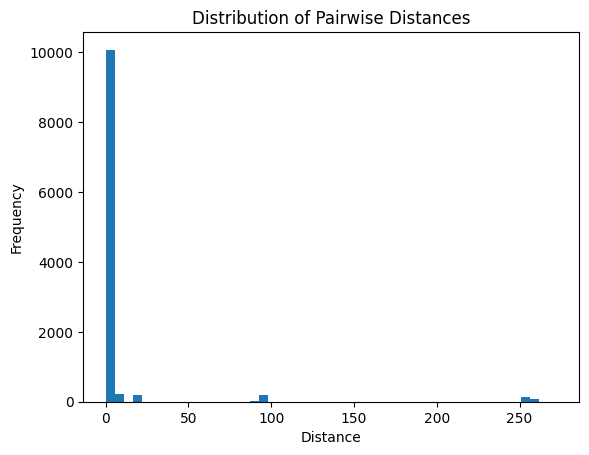

In [6]:
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(X_train_min)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

Как можно заметить, расстояния нерепрезентативны. Это происходит из-за того, что наклоны прямых могут иметь очень разные масштаб, а также могут быть выбросы.

Допустим, для двух экстремумов:
$V1 = [8500, -4300, 1.0]$

$V2 = [8600, -4400, 1.5]$

Евклидово расстояние:
$d = sqrt((8600-8500)^2 + (-4400-(-4300))^2 + (1.5-1.0)^2)
  = sqrt(10000 + 10000 + 0.25)
  ≈ 141$
  
Третий признак (slope=1.0) вообще не влияет на расстояние, потому что первые два признака на порядки больше. Фактически кластеризация идёт только по двум числам, а третье игнорируется.

Плюс, pwlf иногда строит прямые с очень большими по модулю наклонами и очень близкими концами, хотя можно отдалить концы, и тогда наклоны станут адекватнее (это в нашем случае и есть выбросы)

In [13]:
lower = np.percentile(X_train_min, 3, axis=0)
upper = np.percentile(X_train_min, 97, axis=0)
print("Lower percentiles (3%):", lower)
print("Upper percentiles (97%):", upper)

mask = np.all((X_train_min >= lower) & (X_train_min <= upper), axis=1)
X_train_clean = X_train_min[mask]

print(f"Осталось {mask.sum()} из {len(mask)} точек")

Lower percentiles (3%): [-0.46560947 -1.04127737 -1.43627008 -1.4971208 ]
Upper percentiles (97%): [ 0.42853885  1.11924015  0.94865558 -0.02455384]
Осталось 75 из 105 точек


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)

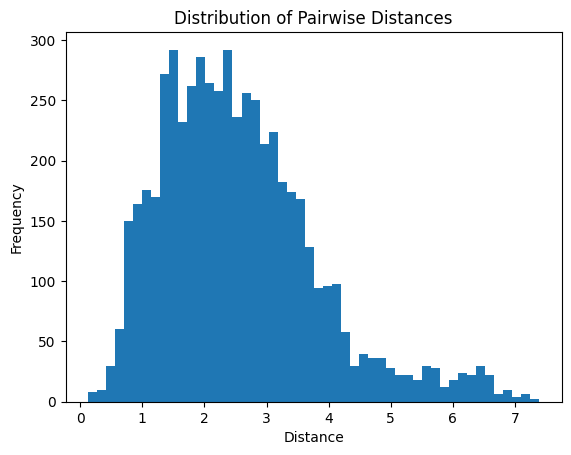

In [15]:
distances = euclidean_distances(X_train_scaled)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [16]:
print("Max values:")
print(np.max(X_train_scaled, axis=0))
print("Min values:")
print(np.min(X_train_scaled, axis=0))
print("Median values:")
print(np.median(X_train_scaled, axis=0))

Max values:
[1.93072501 3.08817754 2.39761138 0.81568216]
Min values:
[-2.78260254 -2.59894753 -2.83214423 -5.29582384]
Median values:
[0.12809532 0.00537503 0.01859917 0.38774428]


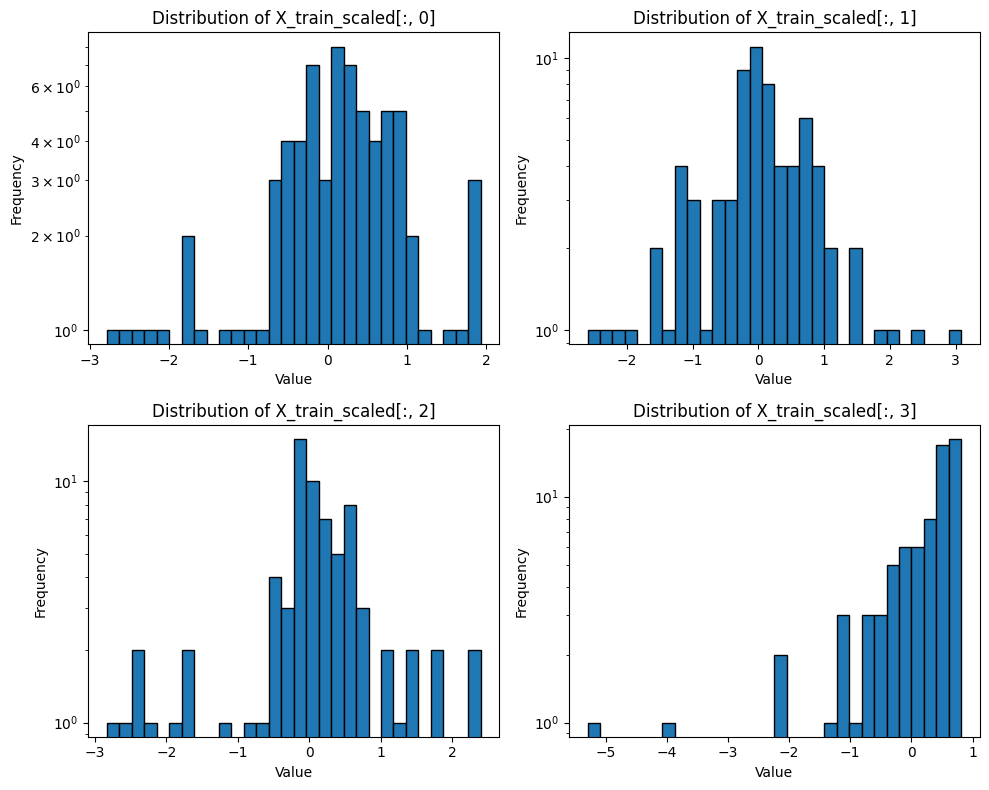

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i in range(4):
    row = i // 2
    col = i % 2
    axes[row, col].hist(X_train_scaled[:, i], bins=30, edgecolor='black')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Distribution of X_train_scaled[:, {i}]')
    axes[row, col].set_yscale('log')

plt.tight_layout()
plt.show()

**DBSCAN**

In [18]:
from sklearn.cluster import DBSCAN

EPS = 1.5
clustering = DBSCAN(eps=EPS, min_samples=5).fit(X_train_scaled)
clustering.labels_

array([ 0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0, -1,  0, -1,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0])

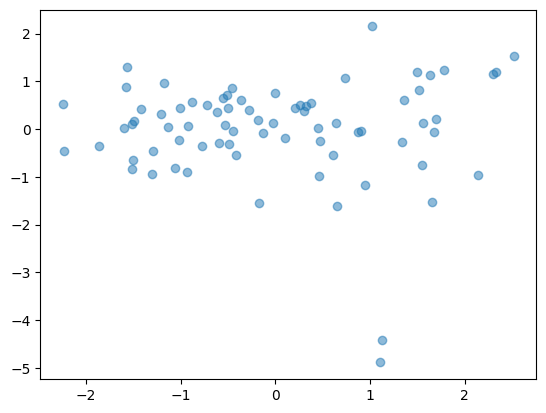

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5)
plt.show()

In [20]:
X_test = build_min_vectors_by_slopes(df_test, N, take_all=True)
X_test_scaled = scaler.transform(X_test)

In [21]:
X_test_scaled.shape

(980, 4)

In [23]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score


def predict_dbscan(X_train, v, eps):
    distances = euclidean_distances([v], X_train[clustering.core_sample_indices_])[0]
    
    min_dist_idx = np.argmin(distances)
    min_dist = distances[min_dist_idx]
    
    if min_dist <= eps:
        return clustering.labels_[clustering.core_sample_indices_[min_dist_idx]]
    else:
        return -1

y_true = df_test['is_min'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_dbscan(X_train_scaled, X_test_scaled[i - N], EPS)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"DBSCAN - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

DBSCAN - Accuracy: 0.3439, Recall: 0.5714, Precision: 0.0124, F1 Score: 0.0243, ROC_AUC: 0.4560


Можно заметить интересное наблюдение. Если добавлять в y_pred (prediction != -1), то метрики следующие:

Accuracy: 0.3439, Recall: 0.5714, Precision: 0.0124, F1 Score: 0.0243, ROC_AUC: 0.4560

Если же инвертировать результат и добавлять (prediction == -1), то результат такой:

Accuracy: 0.6561, Recall: 0.4286, Precision: 0.0179, F1 Score: 0.0344, ROC_AUC: 0.5440

Видим, что метрики немного улучшились, поэтому модель предсказывает инвертированные значения, хотя не сильно ушла от случайной

**KMeans**

In [24]:
from sklearn.cluster import KMeans

clustering = KMeans(n_clusters=2).fit(X_train_scaled)
clustering.labels_

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [25]:
def predict_kmeans(v, threshold=None):
    label = clustering.predict([v])[0]
    
    if threshold is not None:
        dist = euclidean_distances([v], [clustering.cluster_centers_[label]])[0][0]
        if dist > threshold:
            return -1
    
    return label

y_true = df_test['is_min'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_kmeans(X_test_scaled[i - N], threshold=EPS)
    if (prediction == -1):
        print(i)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"Kmeans - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

21
22
23
24
25
26
27
28
29
30
31
32
33
35
36
37
38
40
41
51
52
53
54
55
59
60
62
63
64
65
69
70
71
74
78
79
80
83
84
88
91
101
105
107
110
112
113
114
115
116
117
118
119
120
124
125
126
127
128
129
130
137
138
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
196
197
198
199
200
201
202
204
205
211
213
214
215
216
217
218
219
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
300
302
303
305
307
308
309
310
312
313
314
315
318
319
320
321
322
323
324
325
326
327
328
329
330
332
333
334
335
336
337
338
339
340
341
342
343
344
345
346
347
348
349
350
351
352
353
354
355
356
357
358
3

***Максимумы***

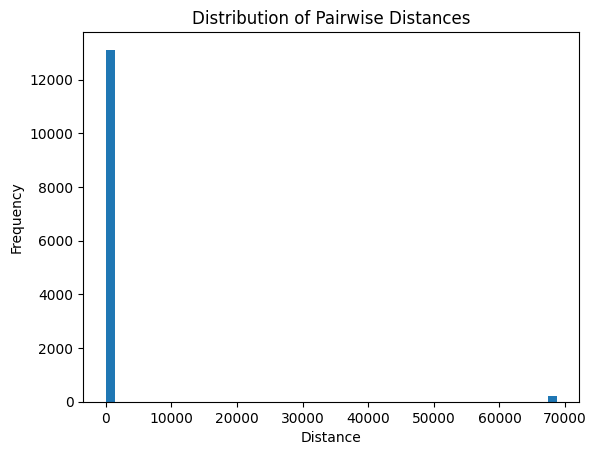

In [26]:
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(X_train_max)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [27]:
lower = np.percentile(X_train_max, 3, axis=0)
upper = np.percentile(X_train_max, 97, axis=0)
print("Lower percentiles (3%):", lower)
print("Upper percentiles (97%):", upper)

mask = np.all((X_train_max >= lower) & (X_train_max <= upper), axis=1)
X_train_clean = X_train_max[mask]

print(f"Осталось {mask.sum()} из {len(mask)} точек")

Lower percentiles (3%): [-6.23662184e-01 -3.56834497e+00 -8.47939816e-01  9.79766122e-04]
Upper percentiles (97%): [0.30681608 0.95317931 1.95074393 1.75781464]
Осталось 90 из 116 точек


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)

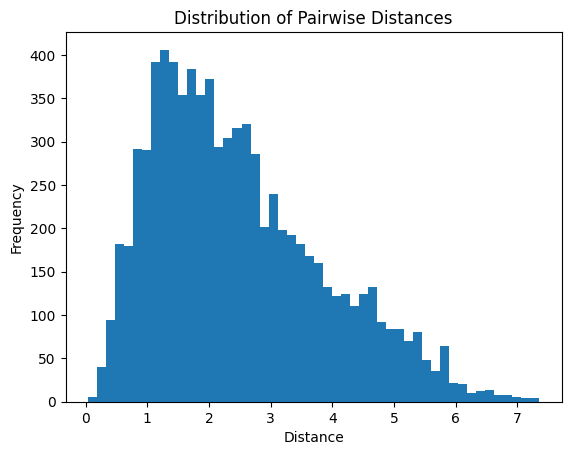

In [29]:
distances = euclidean_distances(X_train_scaled)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [30]:
print("Max values:")
print(np.max(X_train_scaled, axis=0))
print("Min values:")
print(np.min(X_train_scaled, axis=0))
print("Median values:")
print(np.median(X_train_scaled, axis=0))

Max values:
[2.2795883  2.2321451  4.39103074 4.45289323]
Min values:
[-2.63237299 -4.84310131 -2.0354217  -0.90667055]
Median values:
[ 0.04846313  0.08090182 -0.08167801 -0.29219494]


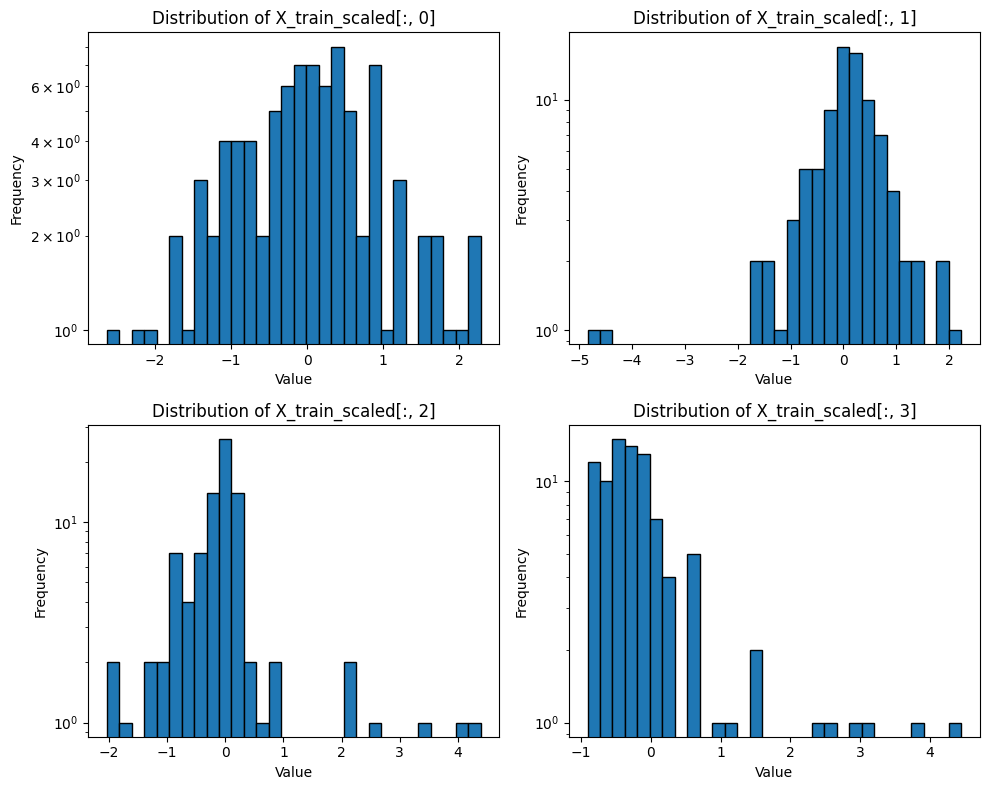

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i in range(4):
    row = i // 2
    col = i % 2
    axes[row, col].hist(X_train_scaled[:, i], bins=30, edgecolor='black')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Distribution of X_train_scaled[:, {i}]')
    axes[row, col].set_yscale('log')

plt.tight_layout()
plt.show()

**DBSCAN**

In [32]:
from sklearn.cluster import DBSCAN

EPS = 1.5
clustering = DBSCAN(eps=EPS, min_samples=5).fit(X_train_scaled)
clustering.labels_

array([ 0, -1,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,
       -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       -1,  0,  0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0,  0, -1,  0, -1,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,  0,
        0,  0,  0, -1,  0,  0, -1,  0, -1,  0,  0,  0,  0, -1,  0,  0,  0,
        0,  0,  0, -1,  0])

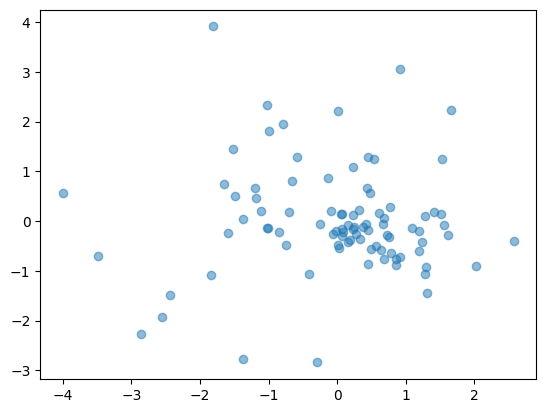

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5)
plt.show()

In [37]:
def predict_dbscan(X_train, v, eps):
    distances = euclidean_distances([v], X_train[clustering.core_sample_indices_])[0]
    
    min_dist_idx = np.argmin(distances)
    min_dist = distances[min_dist_idx]
    
    if min_dist <= eps:
        return clustering.labels_[clustering.core_sample_indices_[min_dist_idx]]
    else:
        return -1

y_true = df_test['is_max'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_dbscan(X_train_scaled, X_test_scaled[i - N], EPS)
    y_pred.append(prediction == -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"DBSCAN - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

DBSCAN - Accuracy: 0.5827, Recall: 0.8333, Precision: 0.0356, F1 Score: 0.0683, ROC_AUC: 0.7056


Можно заметить интересное наблюдение. Если добавлять в y_pred (prediction != -1), то метрики следующие:

Accuracy: 0.4173, Recall: 0.1667, Precision: 0.0054, F1 Score: 0.0104, ROC_AUC: 0.2944

Если же инвертировать результат и добавлять (prediction == -1), то результат такой:

Accuracy: 0.5827, Recall: 0.8333, Precision: 0.0356, F1 Score: 0.0683, ROC_AUC: 0.7056

Можно сделать вывод, что модель предсказывает всё наоборот

**KMeans**

In [38]:
from sklearn.cluster import KMeans

clustering = KMeans(n_clusters=2).fit(X_train_scaled)
clustering.labels_

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1], dtype=int32)

In [40]:
def predict_kmeans(v, threshold=None):
    label = clustering.predict([v])[0]
    
    if threshold is not None:
        dist = euclidean_distances([v], [clustering.cluster_centers_[label]])[0][0]
        if dist > threshold:
            return -1
    
    return label

y_true = df_test['is_max'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_kmeans(X_test_scaled[i - N], threshold=EPS)
    y_pred.append(prediction == -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"Kmeans - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

Kmeans - Accuracy: 0.2622, Recall: 0.9444, Precision: 0.0230, F1 Score: 0.0449, ROC_AUC: 0.5970
